# Synchroextracting Transform (SET)

The **synchroextracting transform** (Yu, Yu & Xu, IEEE TIE 2017) is a
*post-processing* of the short-time Fourier transform (STFT). The
**ideal** time–frequency image of an AM–FM oscillation
$s(t)=A(t)\,e^{i\varphi(t)}$
is a Dirac along the instantaneous frequency (IF)

$$\mathrm{ITFA}(t,\omega)=A(t)\,\delta\bigl(\omega-\varphi'(t)\bigr).$$

Restricted by the Heisenberg principle, a plain STFT $G_e(t,\omega)$
smears energy into a band around $\varphi'(t)$. The **synchrosqueezing
transform** (SST) *gathers* every coefficient that shares the same IF
estimate onto that trajectory:

$$T_s(t,\eta)=\int G_e(t,\omega)\,\delta\bigl(\eta-\omega_0(t,\omega)\bigr)\,d\omega.$$

SET does the opposite of squeezing: it **extracts** only the STFT value
that already sits on the IF, and throws the smear away

$$T_e(t,\omega)=G_e(t,\omega)\,\delta\bigl(\omega-\omega_0(t,\omega)\bigr).$$

The operator $\delta(\omega-\omega_0)$ is the binary **synchroextracting
operator** (SEO). Because the retained numbers are the original STFT
coefficients (not a sum of neighbours), SET is sharper than SST in noise
and still reconstructible: a real mode is simply
$\mathrm{Re}\,T_e(t,\varphi'(t))$.

| | **STFT** | **SST** | **SET** (this notebook) |
|---|---|---|---|
| Post-process | none | squeeze onto IF | extract on IF |
| Energy | smeared band | gathered ridge | single TF bin |
| Reconstruction | invert STFT | integrate a bandwidth | read the ridge of $T_e$ |

**Reference**

> G. Yu, M. Yu, C. Xu, *Synchroextracting Transform*,
> IEEE Transactions on Industrial Electronics 64(10):8042–8054, 2017.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SET
from pysdkit.data import load_set_batdata2, load_set_vibdata

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(SET())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Synchroextracting Transform (SET)


## 2. What the code computes

1. Odd-length Gaussian window on $[-1/2,1/2]$,
   $h(\tau)=\exp(-\pi \tau^2/\sigma^2)$ with $\sigma=0.32$, and its
   derivative $h'$.
2. STFT $G$ of $x$ and STFT $G'$ with $h'$ (MATLAB `tfr1` / `tfr2`).
3. IF correction
   $\omega_0(t,\omega)-\omega \propto -\mathrm{Re}\bigl(i\,G'/G\bigr)$.
4. SEO: keep a bin if $|G|>0.8\,\mathrm{mean}(|x|)$ and the correction
   is less than half a frequency bin.
5. Rectified STFT $G/({\sum h}/2)$; SET is that map times the SEO.


## 3. Paper Example 1 — damped FM tone

$$s(t)=e^{-0.5 t}\sin\bigl(2\pi(25t+10\sin 1.5 t)\bigr),\quad
F_s=100\,\mathrm{Hz},\quad t\in[0,4].$$

The theoretical IF is $25+15\cos(1.5 t)$ Hz. Window length 40 samples
(MATLAB `SET_Y(Sig', 40)`).


Te shape (201, 401)   |Te| max 0.9323686514828029


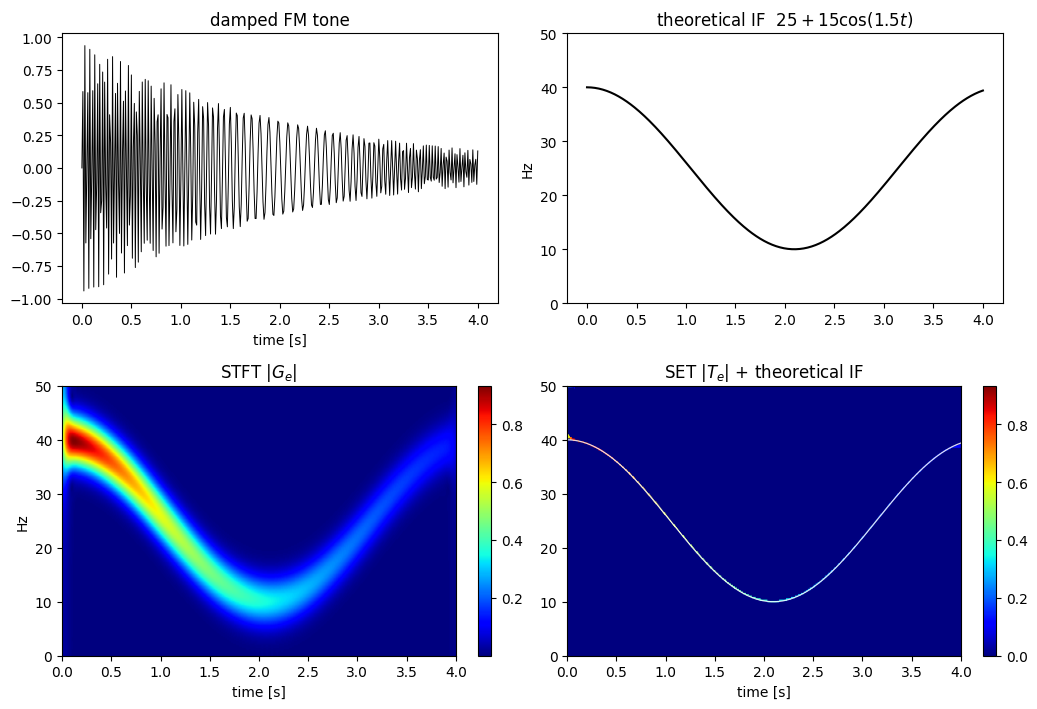

In [2]:
fs = 100.0
t = np.arange(0.0, 4.0 + 1.0 / fs, 1.0 / fs)
sig = np.exp(-0.5 * t) * np.sin(2.0 * np.pi * (25.0 * t + 10.0 * np.sin(1.5 * t)))
inst_freq = 25.0 + 15.0 * np.cos(1.5 * t)

engine = SET(hlength=40, fs=fs)
te, freq = engine.transform(sig)
tfr = engine.tfr_
seo = engine.seo_
print("Te shape", te.shape, "  |Te| max", float(np.max(np.abs(te))))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))
axes[0, 0].plot(t, sig, color="k", lw=0.7)
axes[0, 0].set_title("damped FM tone")
axes[0, 0].set_xlabel("time [s]")
axes[0, 1].plot(t, inst_freq, color="k")
axes[0, 1].set_title("theoretical IF  $25+15\\cos(1.5t)$")
axes[0, 1].set_ylabel("Hz")
axes[0, 1].set_ylim(0, 50)
im = axes[1, 0].imshow(
    np.abs(tfr),
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], freq[0], freq[-1]],
    cmap="jet",
)
axes[1, 0].set_title("STFT $|G_e|$")
axes[1, 0].set_ylabel("Hz")
im2 = axes[1, 1].imshow(
    np.abs(te),
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], freq[0], freq[-1]],
    cmap="jet",
)
axes[1, 1].plot(t, inst_freq, color="w", lw=0.9, alpha=0.85)
axes[1, 1].set_title("SET $|T_e|$ + theoretical IF")
for ax in axes[1]:
    ax.set_xlabel("time [s]")
    ax.set_ylim(0, 50)
fig.colorbar(im, ax=axes[1, 0], fraction=0.046)
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046)
fig.tight_layout()

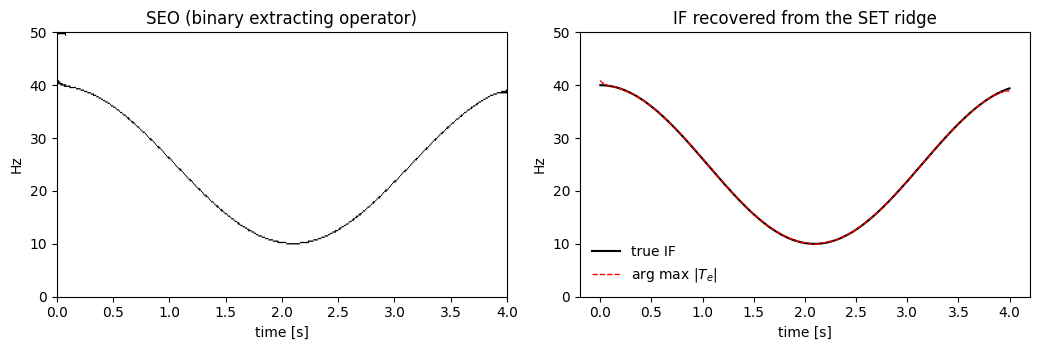

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
axes[0].imshow(
    seo,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], freq[0], freq[-1]],
    cmap="gray_r",
)
axes[0].set_title("SEO (binary extracting operator)")
axes[0].set_ylabel("Hz")
peak_hz = freq[np.argmax(np.abs(te), axis=0)]
axes[1].plot(t, inst_freq, "k-", label="true IF")
axes[1].plot(t, peak_hz, "r--", lw=1.0, label="arg max $|T_e|$")
axes[1].set_title("IF recovered from the SET ridge")
axes[1].set_ylabel("Hz")
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xlabel("time [s]")
    ax.set_ylim(0, 50)
fig.tight_layout()

## 4. Bat echolocation (`Example_3.m`)

Packaged `batdata2.mat`: 400 samples at $F_s=10^6/7$ Hz. MATLAB uses
`SET_Y(detrend(data), 45)`. Four harmonic ridges of the SET map are the
usual echolocation chirps.


N = 400   Fs = 142.9 kHz


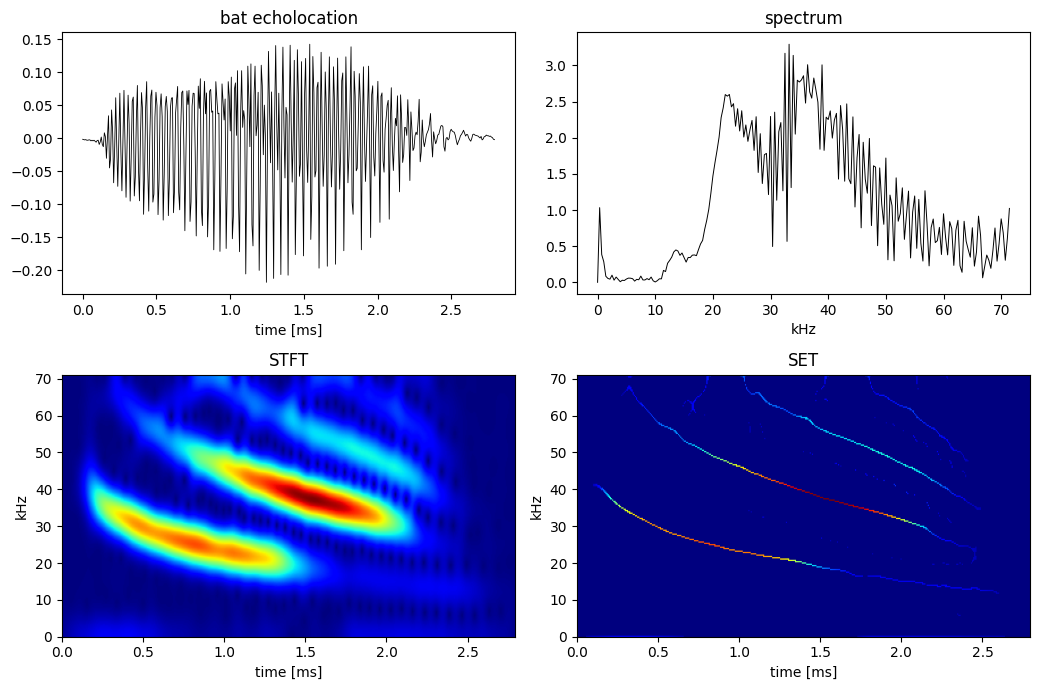

In [4]:
bat = load_set_batdata2()
x = np.asarray(bat["signal"])
x = x - np.mean(x)
fs_b = float(bat["fs"])
t_ms = np.asarray(bat["t"]) * 1e3
freq_khz = None

engine_b = SET(hlength=45, fs=fs_b)
te_b, freq_b = engine_b.transform(x)
freq_khz = freq_b / 1e3
print("N =", x.size, "  Fs = {:.1f} kHz".format(fs_b / 1e3))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0))
axes[0, 0].plot(t_ms, x, color="k", lw=0.6)
axes[0, 0].set_title("bat echolocation")
axes[0, 0].set_xlabel("time [ms]")
spec = np.abs(np.fft.rfft(x))
f_fft = np.fft.rfftfreq(x.size, d=1.0 / fs_b) / 1e3
axes[0, 1].plot(f_fft, spec, color="k", lw=0.7)
axes[0, 1].set_title("spectrum")
axes[0, 1].set_xlabel("kHz")
axes[1, 0].imshow(
    np.abs(engine_b.tfr_),
    aspect="auto",
    origin="lower",
    extent=[t_ms[0], t_ms[-1], freq_khz[0], freq_khz[-1]],
    cmap="jet",
)
axes[1, 0].set_title("STFT")
axes[1, 1].imshow(
    np.abs(te_b),
    aspect="auto",
    origin="lower",
    extent=[t_ms[0], t_ms[-1], freq_khz[0], freq_khz[-1]],
    cmap="jet",
)
axes[1, 1].set_title("SET")
for ax in axes[1]:
    ax.set_xlabel("time [ms]")
    ax.set_ylabel("kHz")
fig.tight_layout()